classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



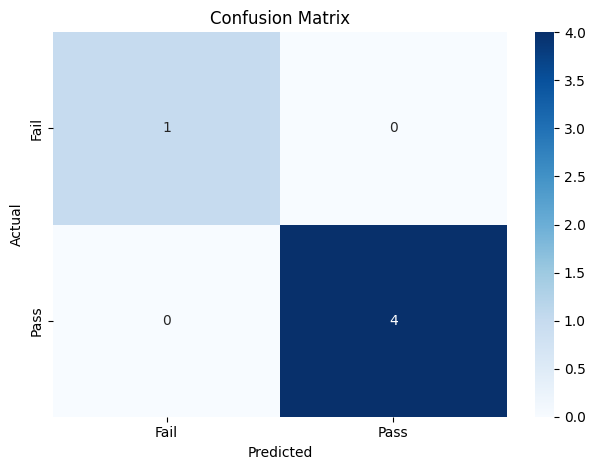

predict your results

Predicted result: Pass


c:\Users\ABHIJITH\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [4]:
# feature scaling
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Student_Performance_Dataset.csv")

le=LabelEncoder()
df['Internet']=le.fit_transform(df['Internet'])
df['Passed']=le.fit_transform(df['Passed'])

features=['StudyHours','Attendance','PastScore','SleepHours']
scaler=StandardScaler()
df_scaled=df.copy()
df_scaled[features]=scaler.fit_transform(df[features])

x=df_scaled[features] #feature
y=df_scaled['Passed'] #target

x_train, x_test, y_train, y_test=train_test_split(x,y,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

print("classification report")
print(classification_report(y_test,y_pred))

conf_matrix=confusion_matrix(y_test,y_pred)
plt.Figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("predict your results\n")
try:
    study_hours=float(input("Enter study hours: "))
    attendance=float(input("Enter attendance percentage: "))
    past_score=float(input("Enter past score: "))
    sleep_hours=float(input("Enter sleep hours: "))
    
    user_input_df=pd.DataFrame({
        'StudyHours':[study_hours],
        'Attendance':[attendance],
        'PastScore':[past_score],
        'SleepHours':[sleep_hours]
    })

    user_input_scaled=scaler.transform(user_input_df)
    prediction=model.predict(user_input_scaled)
    result="Pass" if prediction[0]==1 else "Fail"
    print(f"Predicted result: {result}")
except ValueError:
    print("Invalid input. Please enter numeric values for study hours, attendance, past score, and sleep hours.")